# Employee Salary Prediction System
## AI/ML Regression Model to Predict Accurate Salaries Based on Employee Profile

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the dataset
data = pd.read_csv('DATASET.csv')
print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nData types:\n{data.dtypes}")

Dataset shape: (375, 6)

Columns: ['Age', 'Gender', 'Education', 'Occupation', 'Experience', 'Salary']

Data types:
Age           float64
Gender         object
Education      object
Occupation     object
Experience    float64
Salary        float64
dtype: object


In [3]:
# Display first few rows
data.head(10)

,Age,Gender,Education,Occupation,Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [4]:
# Check for missing values
print("Missing values:")
print(data.isnull().sum())
print(f"\nBasic Statistics:\n{data.describe()}")

Missing values:
Age           2
Gender        2
Education     2
Occupation    2
Experience    2
Salary        2
dtype: int64

Basic Statistics:
              Age  Experience         Salary
count  373.000000  373.000000     373.000000
mean    37.431635   10.030831  100577.345845
std      7.069073    6.557007   48240.013482
min     23.000000    0.000000     350.000000
25%     31.000000    4.000000   55000.000000
50%     36.000000    9.000000   95000.000000
75%     44.000000   15.000000  140000.000000
max     53.000000   25.000000  250000.000000


In [5]:
# Display last few rows
data.tail(10)

,Age,Gender,Education,Occupation,Experience,Salary
365,43.0,Male,Master's,Director of Marketing,18.0,170000.0
366,31.0,Female,Bachelor's,Junior Financial Analyst,3.0,50000.0
367,41.0,Male,Bachelor's,Senior Product Manager,14.0,150000.0
368,44.0,Female,PhD,Senior Data Engineer,16.0,160000.0
369,33.0,Male,Bachelor's,Junior Business Analyst,4.0,60000.0
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


## 3. Data Preprocessing and Feature Engineering

In [6]:
# Create a copy for preprocessing
df = data.copy()

# Handle missing values if any
df = df.dropna()
print(f"Data shape after dropping NaN: {df.shape}")

# Initialize label encoders dictionary to store for later use
label_encoders = {}

# Encode categorical variables
categorical_cols = ['Gender', 'Education', 'Occupation']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col} encoding:")
    for i, class_ in enumerate(le.classes_):
        print(f"  {i}: {class_}")

Data shape after dropping NaN: (373, 6)

Gender encoding:
  0: Female
  1: Male

Education encoding:
  0: Bachelor's
  1: Master's
  2: PhD

Occupation encoding:
  0: Account Manager
  1: Accountant
  2: Administrative Assistant
  3: Business Analyst
  4: Business Development Manager
  5: Business Intelligence Analyst
  6: CEO
  7: Chief Data Officer
  8: Chief Technology Officer
  9: Content Marketing Manager
  10: Copywriter
  11: Creative Director
  12: Customer Service Manager
  13: Customer Service Rep
  14: Customer Service Representative
  15: Customer Success Manager
  16: Customer Success Rep
  17: Data Analyst
  18: Data Entry Clerk
  19: Data Scientist
  20: Digital Content Producer
  21: Digital Marketing Manager
  22: Director
  23: Director of Business Development
  24: Director of Engineering
  25: Director of Finance
  26: Director of HR
  27: Director of Human Capital
  28: Director of Human Resources
  29: Director of Marketing
  30: Director of Operations
  31: Direc

In [7]:
# Prepare features and target
X = df[['Age', 'Experience', 'Gender_encoded', 'Education_encoded', 'Occupation_encoded']]
y = df['Salary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")
print(f"Target range: ${y.min():,.0f} - ${y.max():,.0f}")

Features shape: (373, 5)
Target shape: (373,)

Feature columns: ['Age', 'Experience', 'Gender_encoded', 'Education_encoded', 'Occupation_encoded']
Target range: $350 - $250,000


## 4. Train-Test Split and Model Training

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining salary range: ${y_train.min():,.0f} - ${y_train.max():,.0f}")
print(f"Testing salary range: ${y_test.min():,.0f} - ${y_test.max():,.0f}")

Training set size: 298
Testing set size: 75

Training salary range: $350 - $250,000
Testing salary range: $30,000 - $250,000


In [9]:
# Train Random Forest Regressor
print("Training the Random Forest Model...")
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("✅ Model training completed!")

Training the Random Forest Model...
✅ Model training completed!


## 5. Model Evaluation

In [10]:
# Make predictions on training and testing data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions completed for both training and testing sets.")

Predictions completed for both training and testing sets.


In [11]:
# Calculate evaluation metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"\n📊 R² Score (Coefficient of Determination):")
print(f"  Training R²: {train_r2:.4f}")
print(f"  Testing R²:  {test_r2:.4f}")

print(f"\n📐 RMSE (Root Mean Squared Error):")
print(f"  Training RMSE: ${train_rmse:,.2f}")
print(f"  Testing RMSE:  ${test_rmse:,.2f}")

print(f"\n📏 MAE (Mean Absolute Error):")
print(f"  Training MAE: ${train_mae:,.2f}")
print(f"  Testing MAE:  ${test_mae:,.2f}")
print("\n" + "="*50)

MODEL EVALUATION METRICS

📊 R² Score (Coefficient of Determination):
  Training R²: 0.9725
  Testing R²:  0.9302

📐 RMSE (Root Mean Squared Error):
  Training RMSE: $7,960.86
  Testing RMSE:  $12,936.06

📏 MAE (Mean Absolute Error):
  Training MAE: $5,003.20
  Testing MAE:  $8,866.49



## 6. Visualizations

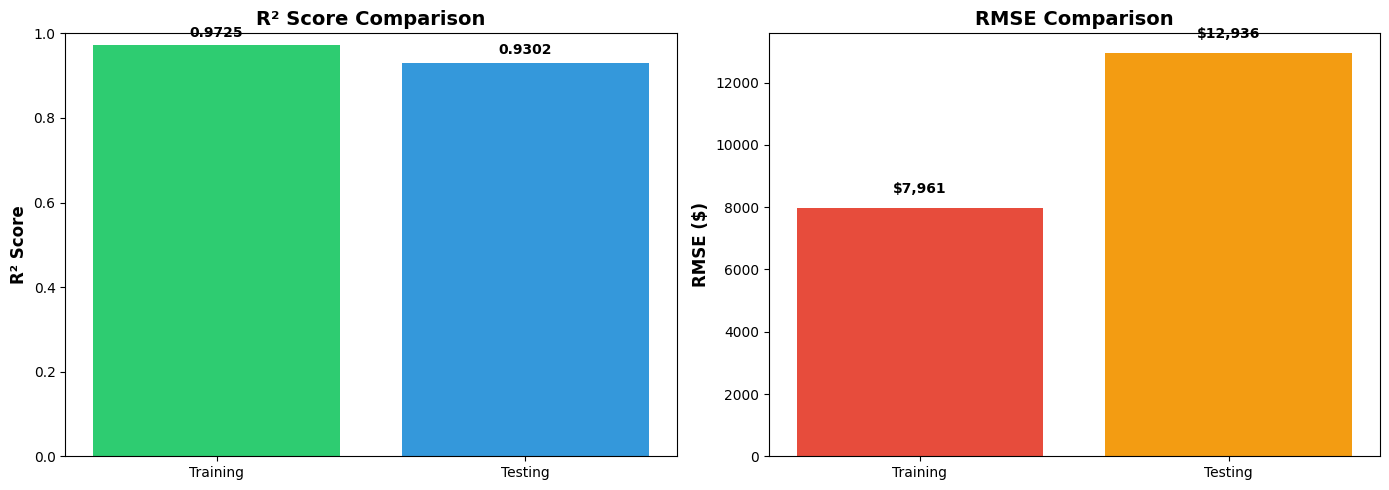

✅ R² and RMSE plot saved!


In [12]:
# Create figure for R² and RMSE scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score
metrics = ['Training', 'Testing']
r2_scores = [train_r2, test_r2]
axes[0].bar(metrics, r2_scores, color=['#2ecc71', '#3498db'])
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE Score
rmse_scores = [train_rmse, test_rmse]
axes[1].bar(metrics, rmse_scores, color=['#e74c3c', '#f39c12'])
axes[1].set_ylabel('RMSE ($)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('r2_rmse_scores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ R² and RMSE plot saved!")

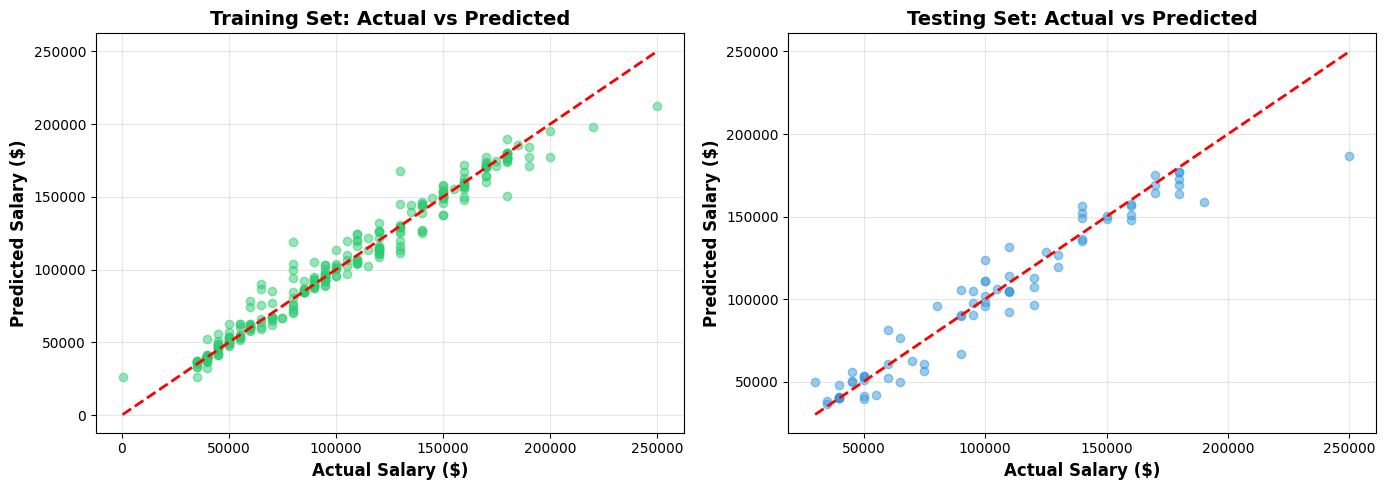

✅ Actual vs Predicted plot saved!


In [13]:
# Create figure for Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data
axes[0].scatter(y_train, y_train_pred, alpha=0.5, color='#2ecc71')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Training Set: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Testing data
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='#3498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Salary ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Testing Set: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Actual vs Predicted plot saved!")

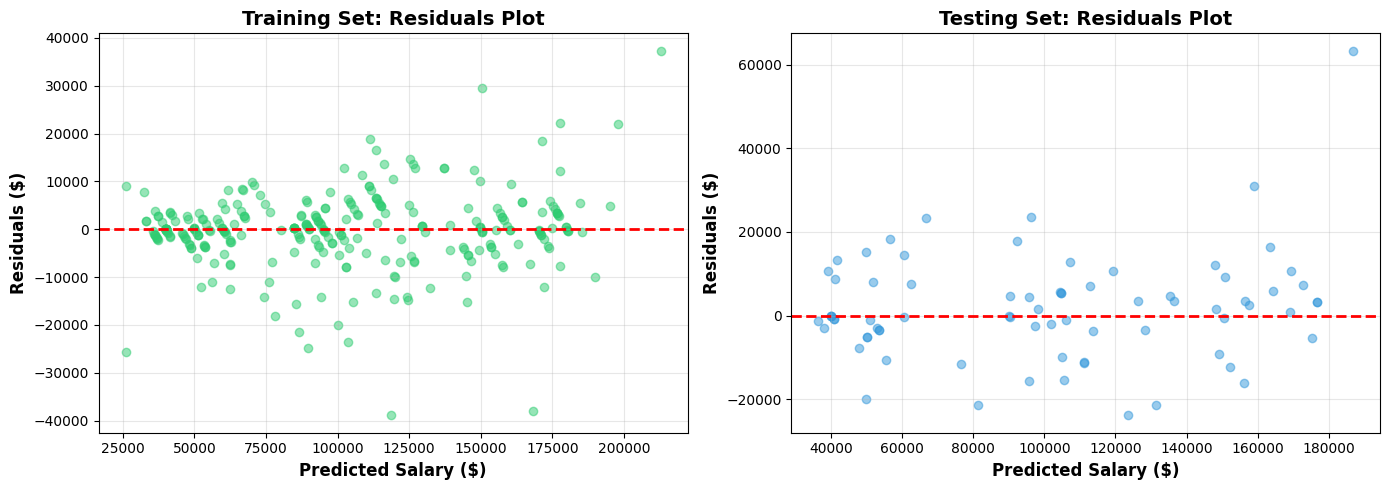

✅ Residuals plot saved!


In [14]:
# Create figure for Residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training residuals
axes[0].scatter(y_train_pred, train_residuals, alpha=0.5, color='#2ecc71')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Training Set: Residuals Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Testing residuals
axes[1].scatter(y_test_pred, test_residuals, alpha=0.5, color='#3498db')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Testing Set: Residuals Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Residuals plot saved!")

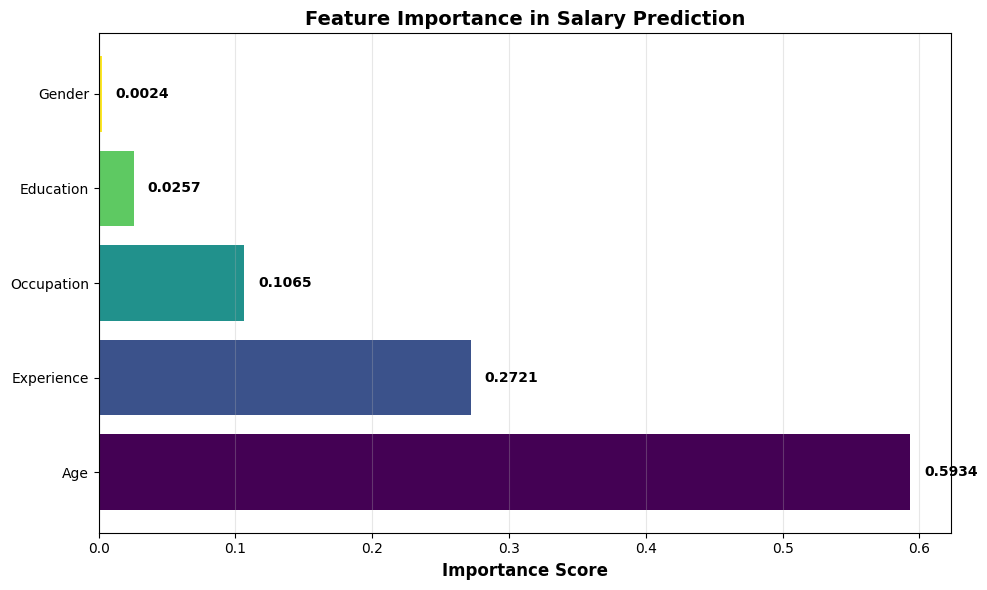

✅ Feature Importance plot saved!

Feature Importance Details:
   Feature  Importance
       Age    0.593365
Experience    0.272083
Occupation    0.106507
 Education    0.025664
    Gender    0.002380


In [15]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': ['Age', 'Experience', 'Gender', 'Education', 'Occupation'],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance in Salary Prediction', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(feature_importance['Importance']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Feature Importance plot saved!")
print("\nFeature Importance Details:")
print(feature_importance.to_string(index=False))

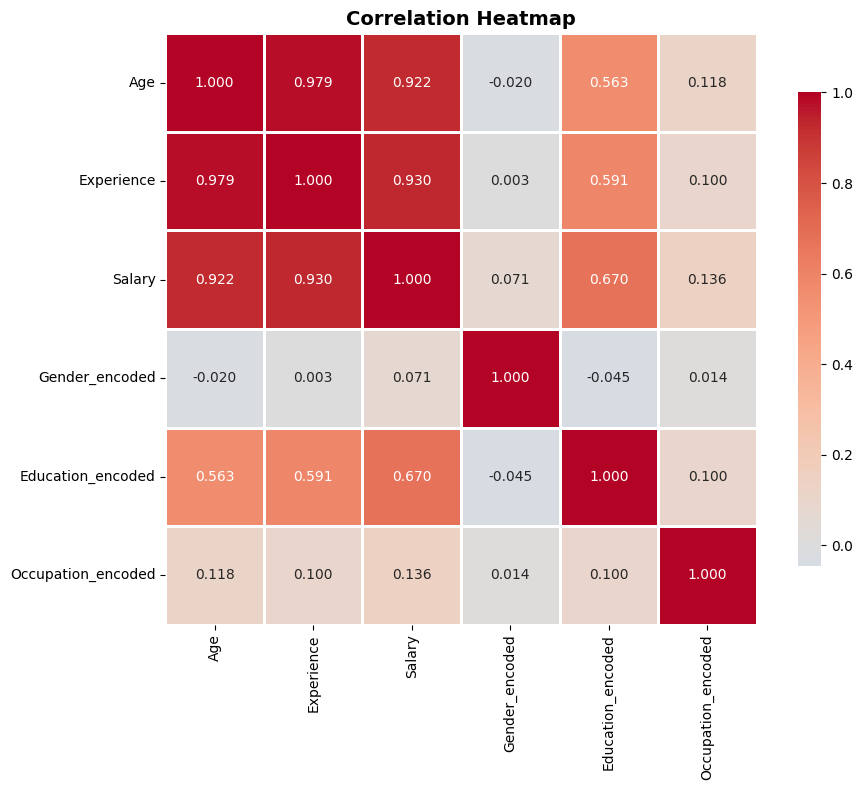

✅ Correlation Heatmap saved!


In [16]:
# Correlation Heatmap
correlation_data = df[['Age', 'Experience', 'Salary']].copy()
correlation_data['Gender_encoded'] = df['Gender_encoded']
correlation_data['Education_encoded'] = df['Education_encoded']
correlation_data['Occupation_encoded'] = df['Occupation_encoded']

fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = correlation_data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Correlation Heatmap saved!")

## 7. Make Predictions on New Data

In [17]:
# Function to predict salary for new employee
def predict_salary(age, gender, education, occupation, experience, label_encoders):
    """
    Predict salary for an employee based on their profile
    """
    try:
        # Encode categorical variables
        gender_encoded = label_encoders['Gender'].transform([gender])[0]
        education_encoded = label_encoders['Education'].transform([education])[0]
        occupation_encoded = label_encoders['Occupation'].transform([occupation])[0]
        
        # Create input array
        input_data = np.array([[age, experience, gender_encoded, education_encoded, occupation_encoded]])
        
        # Make prediction
        predicted_salary = model.predict(input_data)[0]
        
        return predicted_salary
    except Exception as e:
        return f"Error: {str(e)}"

# Test the prediction function
print("Testing prediction function with sample employees:")
print("="*60)

test_cases = [
    {"age": 32, "gender": "Male", "education": "Bachelor's", 
     "occupation": "Software Engineer", "experience": 5},
    {"age": 28, "gender": "Female", "education": "Master's", 
     "occupation": "Data Analyst", "experience": 3},
    {"age": 45, "gender": "Male", "education": "PhD", 
     "occupation": "Senior Manager", "experience": 15},
]

for i, test in enumerate(test_cases, 1):
    predicted = predict_salary(
        test['age'], test['gender'], test['education'],
        test['occupation'], test['experience'], label_encoders
    )
    print(f"\nTest Case {i}:")
    print(f"  Age: {test['age']} | Gender: {test['gender']}")
    print(f"  Education: {test['education']} | Experience: {test['experience']} years")
    print(f"  Occupation: {test['occupation']}")
    print(f"  💰 Predicted Salary: ${predicted:,.2f}")
    print("-"*60)

Testing prediction function with sample employees:

Test Case 1:
  Age: 32 | Gender: Male
  Education: Bachelor's | Experience: 5 years
  Occupation: Software Engineer
  💰 Predicted Salary: $66,651.29
------------------------------------------------------------

Test Case 2:
  Age: 28 | Gender: Female
  Education: Master's | Experience: 3 years
  Occupation: Data Analyst
  💰 Predicted Salary: $66,231.94
------------------------------------------------------------

Test Case 3:
  Age: 45 | Gender: Male
  Education: PhD | Experience: 15 years
  Occupation: Senior Manager
  💰 Predicted Salary: $149,646.15
------------------------------------------------------------


## 8. Model Summary

In [18]:
print("\n" + "="*60)
print("📊 EMPLOYEE SALARY PREDICTION MODEL - SUMMARY")
print("="*60)

print(f"\n📈 Dataset Information:")
print(f"  Total Records: {len(data):,}")
print(f"  Training Records: {len(X_train):,}")
print(f"  Testing Records: {len(X_test):,}")

print(f"\n🎯 Model Configuration:")
print(f"  Algorithm: Random Forest Regressor")
print(f"  Number of Trees: {model.n_estimators}")
print(f"  Max Depth: {model.max_depth}")
print(f"  Input Features: 5")

print(f"\n📊 Performance Metrics:")
print(f"  Training R²: {train_r2:.4f}")
print(f"  Testing R²: {test_r2:.4f}")
print(f"  Testing RMSE: ${test_rmse:,.2f}")
print(f"  Testing MAE: ${test_mae:,.2f}")

print(f"\n✨ Model Interpretation:")
print(f"  The model explains {test_r2*100:.2f}% of the variance in salary predictions.")
print(f"  On average, predictions are off by ${test_mae:,.2f}")

print(f"\n📁 Output Files Generated:")
print(f"  ✓ r2_rmse_scores.png")
print(f"  ✓ actual_vs_predicted.png")
print(f"  ✓ residuals_plot.png")
print(f"  ✓ feature_importance.png")
print(f"  ✓ correlation_heatmap.png")

print("\n" + "="*60)


📊 EMPLOYEE SALARY PREDICTION MODEL - SUMMARY

📈 Dataset Information:
  Total Records: 375
  Training Records: 298
  Testing Records: 75

🎯 Model Configuration:
  Algorithm: Random Forest Regressor
  Number of Trees: 100
  Max Depth: 15
  Input Features: 5

📊 Performance Metrics:
  Training R²: 0.9725
  Testing R²: 0.9302
  Testing RMSE: $12,936.06
  Testing MAE: $8,866.49

✨ Model Interpretation:
  The model explains 93.02% of the variance in salary predictions.
  On average, predictions are off by $8,866.49

📁 Output Files Generated:
  ✓ r2_rmse_scores.png
  ✓ actual_vs_predicted.png
  ✓ residuals_plot.png
  ✓ feature_importance.png
  ✓ correlation_heatmap.png

